In [24]:
import numpy as np
import glob, os, re
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.ndimage import uniform_filter1d

In [25]:
FOLDER   = "/content"                                    # where your .ABS files live
FAMILIES = ["Ni2P-TaON", "ZnO-Ni2P", "TiO2-Ni2P", "pure_Ni2P", "pure_TiO2",
            "Ta3N5", "TaON", "TiO2", "ZnO"]     # most specific FIRST, as always

def _norm(s):
    """Strip case and every separator: 'TaON 1'=='TaON_1'=='taon-1'."""
    return re.sub(r"[^a-z0-9]", "", s.lower())

def parse(fname):
    """Return (family, condition, replicate) or None if family unknown."""
    base = re.sub(r"\.abs$", "", os.path.basename(fname), flags=re.I)
    nb   = _norm(base)
    fam  = next((f for f in FAMILIES if nb.startswith(_norm(f))), None)
    if fam is None:
        return None
    rem = nb[len(_norm(fam)):]                 # leftover after the family name
    m   = re.match(r"([a-z]+)(\d*)", rem)      # e.g. 'syn'+'1', 'bm'+'2'
    if m and m.group(1):                       # named condition: syn / bm
        cond = m.group(1)
        rep  = int(m.group(2)) if m.group(2) else 0
    elif rem.isdigit():                        # bare number = its OWN condition
        cond, rep = rem, 0
    else:
        cond, rep = "0", 0
    return fam, cond, rep

def load_abs(path):
    """Read a 2-column .ABS file, skipping the two '\"'-prefixed header lines."""
    w, a = [], []
    for line in open(path, errors="ignore"):
        line = line.strip()
        if not line or line.startswith('"'):
            continue
        p = line.split()
        if len(p) != 2:
            continue
        try:
            w.append(float(p[0])); a.append(float(p[1]))
        except ValueError:
            continue
    w, a = np.array(w), np.array(a)
    o = np.argsort(w)
    return w[o], a[o]

# --- discover, group by CONDITION, and report so you can eyeball it ---
paths = sorted(glob.glob(f"{FOLDER}/*.ABS") + glob.glob(f"{FOLDER}/*.abs"))
conditions, unknown = {}, []
for p in paths:
    pr = parse(p)
    if pr is None:
        unknown.append(os.path.basename(p)); continue
    fam, cond, rep = pr
    key = f"{fam} · {cond}"                     # e.g. 'TaON · syn', 'TaON · 3'
    conditions.setdefault(key, []).append((os.path.basename(p), *load_abs(p)))

print(f"Found {len(paths)} .ABS files\n")
for key in sorted(conditions):
    files = [it[0] for it in conditions[key]]
    print(f"  {key:18s}  ({len(files)}):  {files}")
print("\nUnrecognized:", unknown if unknown else "none")

Found 26 .ABS files

  Ni2P-TaON · 1       (1):  ['Ni2P-TaON 1.ABS']
  Ni2P-TaON · 2       (1):  ['Ni2P-TaON 2.ABS']
  Ni2P-TaON · bm      (2):  ['Ni2P-TaON bm.ABS', 'Ni2P-TaON bm1.ABS']
  Ni2P-TaON · syn     (2):  ['Ni2P-TaON syn.ABS', 'Ni2P-TaON syn1.ABS']
  Ta3N5 · 1           (1):  ['Ta3N5 1.ABS']
  Ta3N5 · 2           (1):  ['Ta3N5 2.ABS']
  Ta3N5 · 3           (1):  ['Ta3N5 3.ABS']
  Ta3N5 · 4           (1):  ['Ta3N5 4.ABS']
  TaON · 1            (1):  ['TaON 1.ABS']
  TaON · 2            (1):  ['TaON 2.ABS']
  TaON · 3            (1):  ['TaON 3.ABS']
  TaON · 4            (1):  ['TaON 4.ABS']
  TaON · bm           (2):  ['TaON bm1.ABS', 'TaON bm2.ABS']
  TaON · syn          (2):  ['TaON syn.ABS', 'TaON syn1.ABS']
  TiO2-Ni2P · 1       (1):  ['TiO2-Ni2P 1.ABS']
  TiO2-Ni2P · 2       (1):  ['TiO2-Ni2P 2.ABS']
  ZnO · 1             (1):  ['ZnO 1.ABS']
  ZnO · 2             (1):  ['ZnO 2.ABS']
  ZnO-Ni2P · 1        (1):  ['ZnO-Ni2P 1.ABS']
  ZnO-Ni2P · 2        (1):  ['ZnO-Ni2P 2.AB

In [26]:
HC = 1239.841984   # eV·nm, so E(eV) = HC / λ(nm)

def to_tauc(w, a, r=0.5):
    """
    Absorbance -> Reflectance -> Kubelka-Munk -> Tauc axes.
      r = 0.5  -> direct-allowed gap, y = (F·hv)^2   (TaON, Ta3N5, ZnO all direct)
      r = 2.0  -> indirect gap,       y = (F·hv)^0.5
    """
    m = (w >= 250) & (w <= 1050)
    w, a = w[m], a[m]
    # Baseline: below the gap an ideal semiconductor is transparent, so any
    # absorbance at 900-1050 nm is drift (or, for Ni2P, metallic background).
    off = np.median(a[(w >= 900) & (w <= 1050)])
    a = a - off
    R = np.clip(10.0 ** (-a), 1e-4, 0.9999)     # A = log10(1/R)  ->  R = 10^(-A)
    F = (1 - R) ** 2 / (2 * R)                   # Kubelka-Munk:  F(R) ∝ α/S
    E = HC / w
    y = (F * E) ** (1.0 / r)                     # Tauc transform
    o = np.argsort(E)
    return E[o], y[o], off

def fit_gap(E, y, e_lo, e_hi, win=45, smooth=15):
    """
    Fit the linear region AT THE INFLECTION POINT of the edge (steepest slope),
    then extrapolate to y=0. Includes a physical sanity guard.
    """
    ys  = uniform_filter1d(y, smooth)
    dys = uniform_filter1d(np.gradient(ys, E), smooth)
    m = (E >= e_lo) & (E <= e_hi)
    if m.sum() < win:
        return None
    idx = np.where(m)[0]
    i   = idx[np.argmax(dys[idx])]              # steepest point of the rising edge
    lo, hi = max(0, i - win // 2), min(len(E), i + win // 2)
    xs, ysub = E[lo:hi], y[lo:hi]
    res = linregress(xs, ysub)
    if res.slope <= 0:
        return None
    Eg   = -res.intercept / res.slope
    back = xs[0] - Eg                            # how far below the window we extrapolate
    r2   = res.rvalue ** 2
    # GUARD: a real edge extrapolates <=0.5 eV back. R^2 alone cannot catch a
    # perfect fit to the wrong slope (that's how you get Eg=1.8 with R2=0.9999).
    if not (-0.05 <= back <= 0.50):
        q = "REJECT-unphysical"
    else:
        q = "OK" if r2 >= 0.97 else "MARGINAL" if r2 >= 0.90 else "POOR"
    return dict(Eg=Eg, r2=r2, quality=q, slope=res.slope,
                intercept=res.intercept, e0=xs[0], e1=xs[-1])

# Where each family's absorption edge lives (eV). Keeps the fitter honest.
SEARCH = {
    "TaON":      (2.15, 2.95),
    "Ni2P-TaON": (2.15, 2.95),
    "Ta3N5":     (1.80, 2.60),   # smaller gap than TaON -> lower window
    "ZnO":       (2.95, 3.60),
    "ZnO-Ni2P":  (2.95, 3.60),
    "TiO2":      (2.90, 3.60),   # anatase edge
    "pure_TiO2": (2.90, 3.60),
    "TiO2-Ni2P": (2.90, 3.60),
    "pure_Ni2P": (1.50, 3.50),   # metallic: NO real edge -- expect REJECT (that's the point)
}

# Tauc exponent per family. Anatase TiO2 is INDIRECT-gap (r=2);
# everything else here is direct-allowed (r=1/2).
R_EXP = {"TiO2": 2.0, "pure_TiO2": 2.0, "TiO2-Ni2P": 2.0}

In [27]:
rows = []
for key in sorted(conditions):
    fam = key.split(" · ")[0]
    e_lo, e_hi = SEARCH[fam]
    for name, w, a in conditions[key]:
        E, y, off = to_tauc(w, a, r=R_EXP.get(fam, 0.5))
        f = fit_gap(E, y, e_lo, e_hi)
        if f:
            rows.append(dict(condition=key, file=name,
                             Eg_eV=round(f["Eg"], 3), R2=round(f["r2"], 3),
                             sub_gap_bg=round(off, 3), quality=f["quality"]))
        else:
            rows.append(dict(condition=key, file=name, Eg_eV=None,
                             R2=None, sub_gap_bg=round(off, 3), quality="FAILED"))

import pandas as pd
df = pd.DataFrame(rows)
print(df.to_string(index=False))

# condition-level means, sane fits only
sane = df[df.quality.isin(["OK", "MARGINAL", "POOR"])]
summary = sane.groupby("condition")["Eg_eV"].agg(["mean", "std", "count"]).round(3)
print("\n=== BAND GAP BY CONDITION (sane fits only) ===")
print(summary.to_string())
df.to_csv("/content/band_gaps.csv", index=False)

      condition               file  Eg_eV    R2  sub_gap_bg           quality
  Ni2P-TaON · 1    Ni2P-TaON 1.ABS  2.621 0.142       1.371              POOR
  Ni2P-TaON · 2    Ni2P-TaON 2.ABS  2.385 0.143       0.803              POOR
 Ni2P-TaON · bm   Ni2P-TaON bm.ABS  2.559 0.204       0.697              POOR
 Ni2P-TaON · bm  Ni2P-TaON bm1.ABS  1.196 0.003       0.752 REJECT-unphysical
Ni2P-TaON · syn  Ni2P-TaON syn.ABS  2.646 0.090       0.902              POOR
Ni2P-TaON · syn Ni2P-TaON syn1.ABS  2.592 0.357       0.786              POOR
      Ta3N5 · 1        Ta3N5 1.ABS  2.129 0.981       0.067                OK
      Ta3N5 · 2        Ta3N5 2.ABS  2.005 0.281       0.291              POOR
      Ta3N5 · 3        Ta3N5 3.ABS  2.123 0.967      -0.103          MARGINAL
      Ta3N5 · 4        Ta3N5 4.ABS  2.008 0.392       0.236              POOR
       TaON · 1         TaON 1.ABS  2.616 0.119       0.308              POOR
       TaON · 2         TaON 2.ABS  2.673 0.782       0.008     

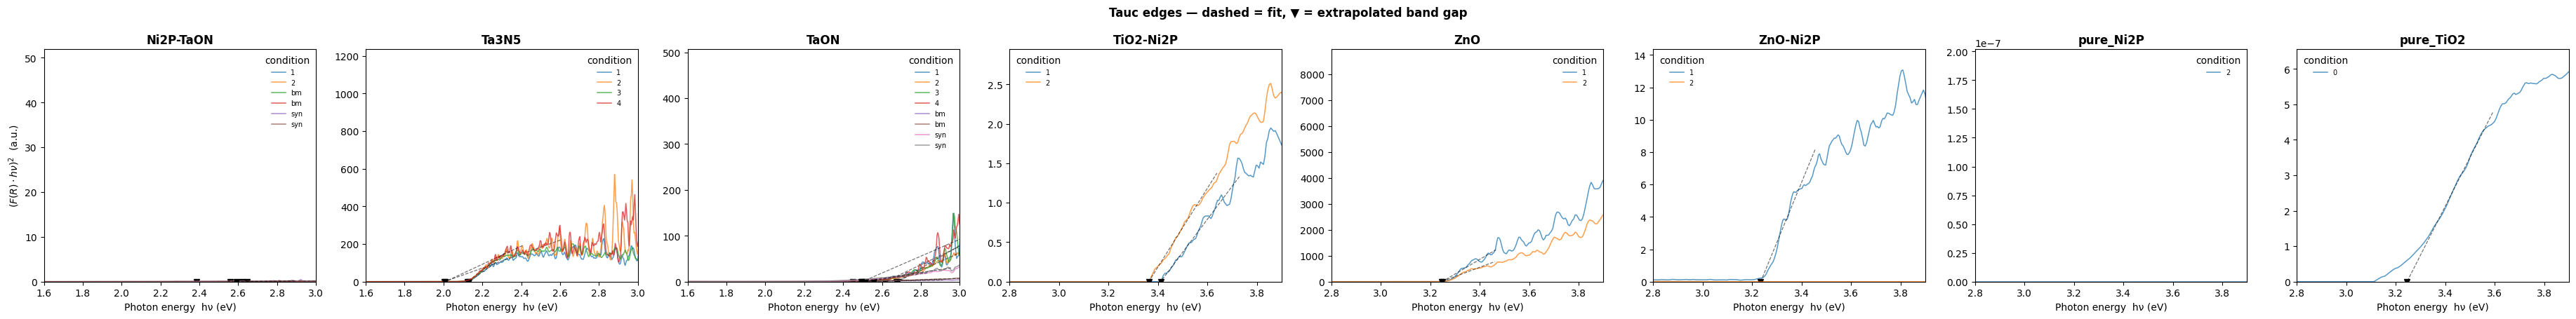

In [28]:
# One panel per family. Each condition's Tauc curve, with its fitted line
# and the extrapolated Eg (▼) drawn on top. This is where you DECIDE which
# fits to trust -- by eye, not by R2 alone.

fams = sorted(set(k.split(" · ")[0] for k in conditions))
fig, axes = plt.subplots(1, len(fams), figsize=(4.6*len(fams), 4.6))
if len(fams) == 1:
    axes = [axes]

for ax, fam in zip(axes, fams):
    e_lo, e_hi = SEARCH[fam]
    for key in sorted(k for k in conditions if k.startswith(fam + " ")):
        for name, w, a in conditions[key]:
            E, y, off = to_tauc(w, a, r=R_EXP.get(fam, 0.5))
            f = fit_gap(E, y, e_lo, e_hi)
            label = key.split("·")[1].strip()
            ax.plot(E, y, lw=1.1, alpha=0.75, label=label)
            if f and f["quality"] != "REJECT-unphysical":
                xx = np.linspace(f["Eg"]-0.05, f["e1"]+0.05, 12)
                ax.plot(xx, f["slope"]*xx + f["intercept"], "k--", lw=0.9, alpha=0.55)
                ax.plot(f["Eg"], 0, "kv", ms=6)          # ▼ marks extrapolated Eg
    # zoom to where each family's edge lives
    lo, hi = (1.6, 3.0) if fam in ("TaON", "Ni2P-TaON", "Ta3N5") else (2.8, 3.9)
    ax.set_xlim(lo, hi); ax.set_ylim(0, None)
    ax.set_title(fam, fontweight="bold"); ax.set_xlabel("Photon energy  hν (eV)")
    ax.legend(fontsize=7, frameon=False, title="condition")
axes[0].set_ylabel(r"$(F(R)\cdot h\nu)^2$  (a.u.)")
fig.suptitle("Tauc edges — dashed = fit, ▼ = extrapolated band gap", fontweight="bold")
fig.tight_layout()
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Mulliken absolute electronegativities (eV), Pearson tabulation
X = {"Ti":3.45, "O":7.54, "Zn":4.45, "Ta":4.11, "N":7.30, "Nb":4.00, "Mo":3.90}
E_FREE = 4.5   # electron energy on the hydrogen scale (eV)

def band_edges(atoms, Eg):
    """
    Xu-Schoonen / Butler-Ginley empirical band edges vs NHE.
      X   = geometric mean of atomic electronegativities
      CBM = X - E_free - 0.5*Eg      (conduction band minimum)
      VBM = CBM + Eg                  (valence band maximum)
    Needs only the band gap + constants -- so YOUR measured gaps feed straight in.
    """
    Xc = np.prod([X[a] for a in atoms]) ** (1.0 / len(atoms))
    cb = Xc - E_FREE - 0.5 * Eg
    return cb, cb + Eg

# CALIBRATION FIRST -- never trust the nitrides until the oxides check out
for name, atoms, Eg, known in [("TiO2", ["Ti","O","O"], 3.20, -0.29),
                               ("ZnO",  ["Zn","O"],      3.25, -0.31)]:
    cb, vb = band_edges(atoms, Eg)
    print(f"{name}: CBM calc = {cb:+.2f} V  (literature ~ {known:+.2f} V)")

TiO2: CBM calc = -0.29 V  (literature ~ -0.29 V)
ZnO: CBM calc = -0.33 V  (literature ~ -0.31 V)


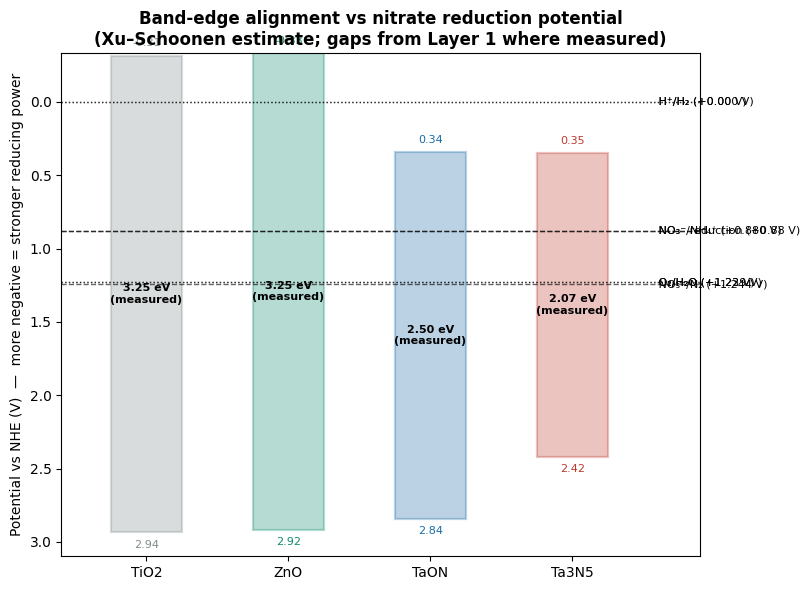

In [31]:
# Each support: a bar from VBM (bottom) to CBM (top). Redox potentials as lines.
# Gap sources: 'exp' = your Layer 1 Tauc measurement, 'lit' = literature.
MATS = [
    ("TiO2",  ["Ti","O","O"],                       3.25, "exp"),   # YOUR indirect-fit Tauc value
    ("ZnO",   ["Zn","O"],                            3.25, "exp"),
    ("TaON",  ["Ta","O","N"],                        2.50, "exp"),
    ("Ta3N5", ["Ta","Ta","Ta","N","N","N","N","N"],  2.07, "exp"),
]
COLORS = {"TiO2":"#7f8c8d", "ZnO":"#0e8a6e", "TaON":"#1b6ca8", "Ta3N5":"#c0392b"}

# --- redox reference potentials vs NHE (pH 0) ---
# !!  CONFIRM the nitrate value from your thesis -- it depends on pathway & pH  !!
  # <<< STILL A PLACEHOLDER -- set YOUR pathway/pH value from the thesis    # NO3-/NH4+ placeholder; replace with YOUR system's value
H_H2, O2_H2O  = 0.00, 1.23

fig, ax = plt.subplots(figsize=(8.2, 6))
for i, (name, atoms, Eg, src) in enumerate(MATS):
    cb, vb = band_edges(atoms, Eg)
    c = COLORS[name]
    ax.bar(i, vb - cb, bottom=cb, width=0.5, color=c, alpha=0.30, edgecolor=c, lw=1.6)
    ax.text(i, cb - 0.12, f"{cb:.2f}", ha="center", va="top",    fontsize=8, color=c)
    ax.text(i, vb + 0.12, f"{vb:.2f}", ha="center", va="bottom", fontsize=8, color=c)
    tag = "measured" if src == "exp" else "literature"
    ax.text(i, (cb+vb)/2, f"{Eg:.2f} eV\n({tag})", ha="center", va="center",
            fontsize=8, fontweight="bold")
REDOX = [
    (0.000, "H⁺/H₂",        ":"),
    (0.880, "NO₃⁻/NH₄⁺",    "--"),   # Wei, Adamson, Vela ChemNanoMat 2020
    (1.229, "O₂/H₂O",       ":"),
    (1.244, "NO₃⁻/N₂",      "--"),
]
for pot, lab, ls in REDOX:
    ax.axhline(pot, color="k", lw=1, ls=ls, alpha=0.6)
    ax.text(len(MATS) - 0.42, pot, f" {lab} ({pot:+.3f} V)", va="center", fontsize=8)
for pot, lab, ls in [(NO3_REDUCTION, "NO₃⁻ reduction", "--"),
                     (H_H2, "H⁺/H₂", ":"), (O2_H2O, "O₂/H₂O", ":")]:
    ax.axhline(pot, color="k", lw=1, ls=ls, alpha=0.6)
    ax.text(len(MATS) - 0.42, pot, f" {lab} ({pot:+.2f} V)", va="center", fontsize=8)

ax.set_xticks(range(len(MATS))); ax.set_xticklabels([m[0] for m in MATS])
ax.set_ylabel("Potential vs NHE (V)  —  more negative = stronger reducing power")
ax.invert_yaxis()                     # photocatalysis convention: negative at top
ax.set_title("Band-edge alignment vs nitrate reduction potential\n"
             "(Xu–Schoonen estimate; gaps from Layer 1 where measured)",
             fontweight="bold")
ax.set_xlim(-0.6, len(MATS) - 0.1)
plt.tight_layout()
plt.show()